#Name: OBAJE PAUL
###Github Repository Link:

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2954s 17us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


In [3]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Classes:")
for i, name in enumerate(class_names):
    print(i, "-", name)

Classes:
0 - airplane
1 - automobile
2 - bird
3 - cat
4 - deer
5 - dog
6 - frog
7 - horse
8 - ship
9 - truck


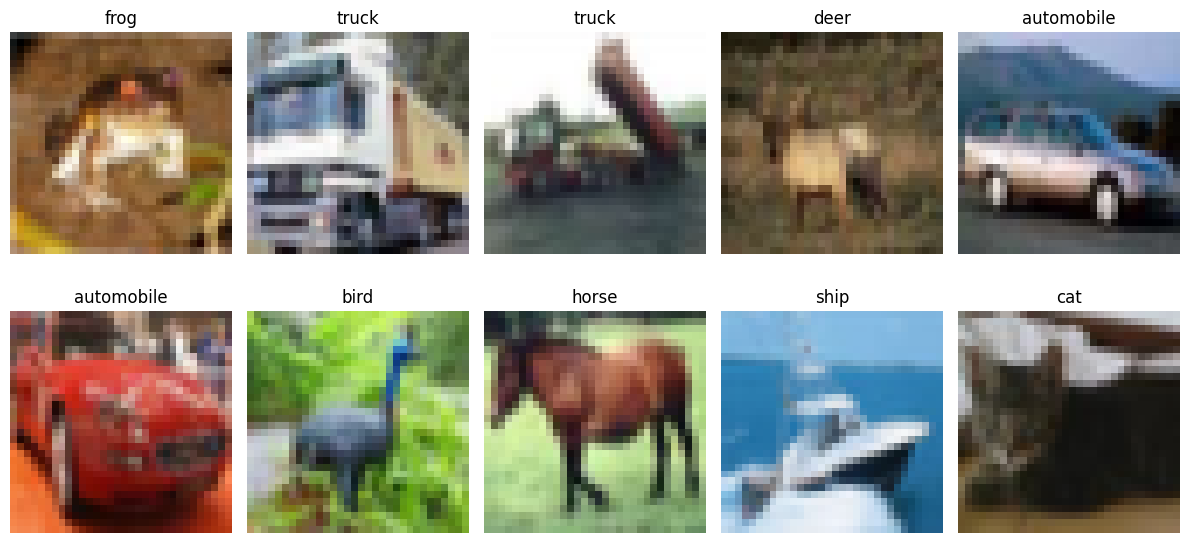

In [4]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

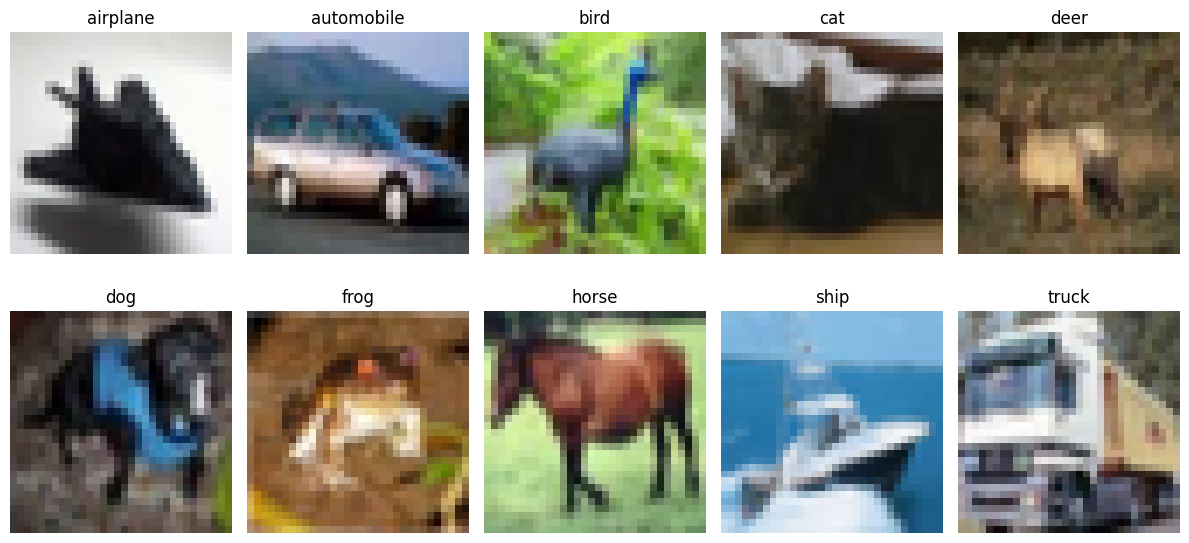

In [5]:
plt.figure(figsize=(12, 6))

for class_id in range(10):
    index = np.where(y_train.flatten() == class_id)[0][0]

    plt.subplot(2, 5, class_id + 1)
    plt.imshow(x_train[index])
    plt.title(class_names[class_id])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [7]:
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

print("Original label shape:", y_train.shape)
print("Categorical label shape:", y_train_cat.shape)
print("Example categorical label:", y_train_cat[0])

Original label shape: (50000, 1)
Categorical label shape: (50000, 10)
Example categorical label: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [8]:
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,258 (3.01 MB)

 Trainable params: 789,258 (3.01 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_baseline = baseline_model.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.3208 - loss: 1.9218 - val_accuracy: 0.3350 - val_loss: 1.8628
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3844 - loss: 1.7371 - val_accuracy: 0.3990 - val_loss: 1.7235
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.4073 - loss: 1.6718 - val_accuracy: 0.4030 - val_loss: 1.6692
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4247 - loss: 1.6208 - val_accuracy: 0.4282 - val_loss: 1.6268
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4400 - loss: 1.5809 - val_accuracy: 0.4256 - val_loss: 1.6076
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4472 - loss: 1.5563 - val_accuracy: 0.4260 - val_loss: 1.6411
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4569 - loss: 1.5302 - val_accuracy: 0.4546 - val_loss: 1.5577
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4608 - loss: 1.5162 - val_

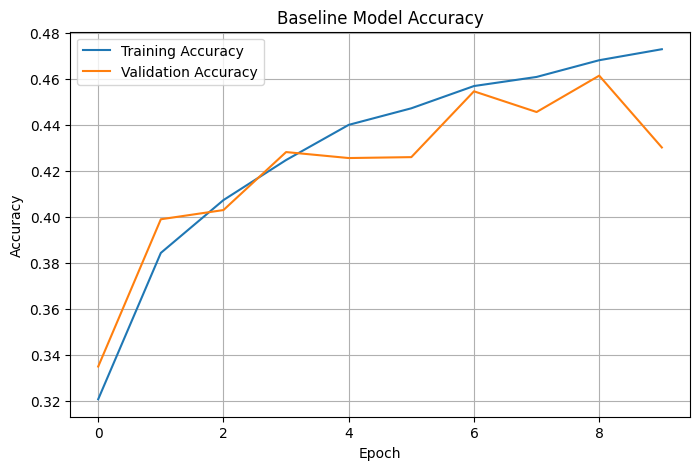

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history_baseline.history["accuracy"], label="Training Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Validation Accuracy")

plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

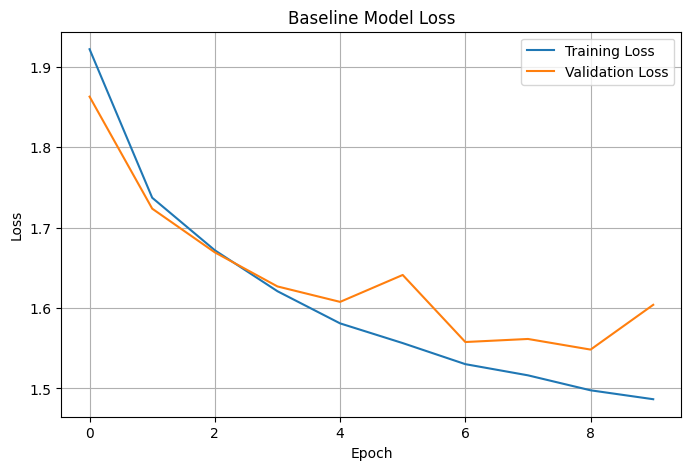

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history_baseline.history["loss"], label="Training Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")

plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [12]:
baseline_loss, baseline_accuracy = baseline_model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print("Baseline Test Loss:", baseline_loss)
print("Baseline Test Accuracy:", baseline_accuracy)

Baseline Test Loss: 1.580837607383728
Baseline Test Accuracy: 0.43070000410079956


In [13]:
improved_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

improved_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_improved = improved_model.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.2372 - loss: 2.0441 - val_accuracy: 0.3086 - val_loss: 1.9085
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.2873 - loss: 1.9231 - val_accuracy: 0.3390 - val_loss: 1.8474
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3048 - loss: 1.8872 - val_accuracy: 0.3516 - val_loss: 1.8316
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.3203 - loss: 1.8532 - val_accuracy: 0.3574 - val_loss: 1.8186
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3277 - loss: 1.8364 - val_accuracy: 0.3604 - val_loss: 1.8055
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3377 - loss: 1.8153 - val_accuracy: 0.3436 - val_loss: 1.7972
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3448 - loss: 1.7964 - val_accuracy: 0.3900 - val_loss: 1.7454
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3512 - loss: 1.7811 - 

In [15]:
improved_loss, improved_accuracy = improved_model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print("Improved Test Loss:", improved_loss)
print("Improved Test Accuracy:", improved_accuracy)

Improved Test Loss: 1.762820839881897
Improved Test Accuracy: 0.3783999979496002


In [16]:
print("MODEL COMPARISON")
print("-" * 35)
print(f"Baseline Accuracy:  {baseline_accuracy:.4f}")
print(f"Improved Accuracy:  {improved_accuracy:.4f}")

if improved_accuracy > baseline_accuracy:
    print("The improved model performed better.")
elif improved_accuracy < baseline_accuracy:
    print("The baseline model performed better.")
else:
    print("Both models achieved the same accuracy.")

MODEL COMPARISON
-----------------------------------
Baseline Accuracy:  0.4307
Improved Accuracy:  0.3784
The baseline model performed better.


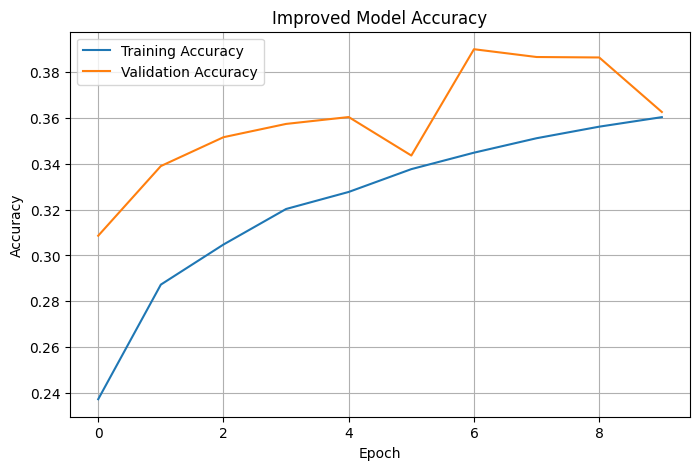

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history_improved.history["accuracy"], label="Training Accuracy")
plt.plot(history_improved.history["val_accuracy"], label="Validation Accuracy")

plt.title("Improved Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

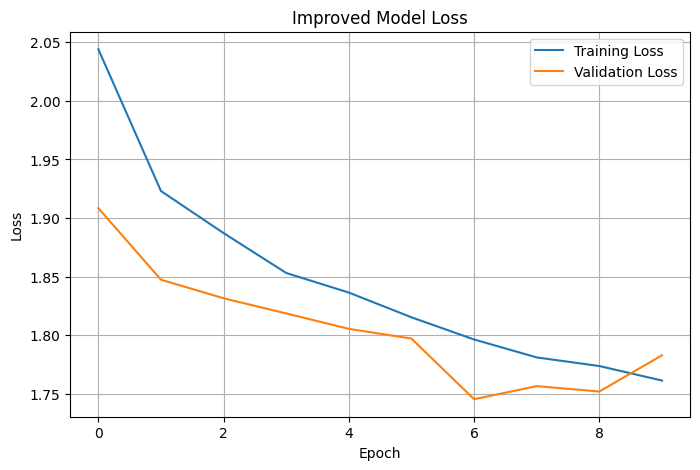

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history_improved.history["loss"], label="Training Loss")
plt.plot(history_improved.history["val_loss"], label="Validation Loss")

plt.title("Improved Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
from sklearn.model_selection import train_test_split

x_train_aug, x_val_aug, y_train_aug, y_val_aug = train_test_split(
    x_train,
    y_train_cat,
    test_size=0.1,
    random_state=42,
    stratify=y_train.flatten()
)

print("Augmented training data:", x_train_aug.shape)
print("Validation data:", x_val_aug.shape)

Augmented training data: (45000, 32, 32, 3)
Validation data: (5000, 32, 32, 3)


In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_datagen.fit(x_train_aug)

print("Data augmentation is ready.")

Data augmentation is ready.


In [21]:
augmented_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

augmented_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

augmented_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_augmented = augmented_model.fit(
    train_datagen.flow(
        x_train_aug,
        y_train_aug,
        batch_size=64
    ),
    epochs=10,
    validation_data=(x_val_aug, y_val_aug),
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 59ms/step - accuracy: 0.2254 - loss: 2.0654 - val_accuracy: 0.2982 - val_loss: 1.9290
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.2768 - loss: 1.9555 - val_accuracy: 0.3380 - val_loss: 1.8765
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.2895 - loss: 1.9225 - val_accuracy: 0.3436 - val_loss: 1.8346
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.3010 - loss: 1.9016 - val_accuracy: 0.3530 - val_loss: 1.7942
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.3084 - loss: 1.8891 - val_accuracy: 0.3716 - val_loss: 1.7670
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.3128 - loss: 1.8748 - val_accuracy: 0.3716 - val_loss: 1.7700
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.3148 - loss: 1.8666 - val_accuracy: 0.3794 - val_loss: 1.7830
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.3227 - loss: 1.8574 - 

In [23]:
augmented_loss, augmented_accuracy = augmented_model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print("Augmented Test Loss:", augmented_loss)
print("Augmented Test Accuracy:", augmented_accuracy)

Augmented Test Loss: 1.732832431793213
Augmented Test Accuracy: 0.3950999975204468


In [24]:
print("FINAL MODEL COMPARISON")
print("=" * 45)

print(f"Baseline Model:   {baseline_accuracy:.4f}")
print(f"Improved Model:   {improved_accuracy:.4f}")
print(f"Augmented Model:  {augmented_accuracy:.4f}")

accuracies = {
    "Baseline": baseline_accuracy,
    "Improved": improved_accuracy,
    "Augmented": augmented_accuracy
}

best_model_name = max(accuracies, key=accuracies.get)

print("\nBest model:", best_model_name)
print(f"Best accuracy: {accuracies[best_model_name]:.4f}")

FINAL MODEL COMPARISON
Baseline Model:   0.4307
Improved Model:   0.3784
Augmented Model:  0.3951

Best model: Baseline
Best accuracy: 0.4307


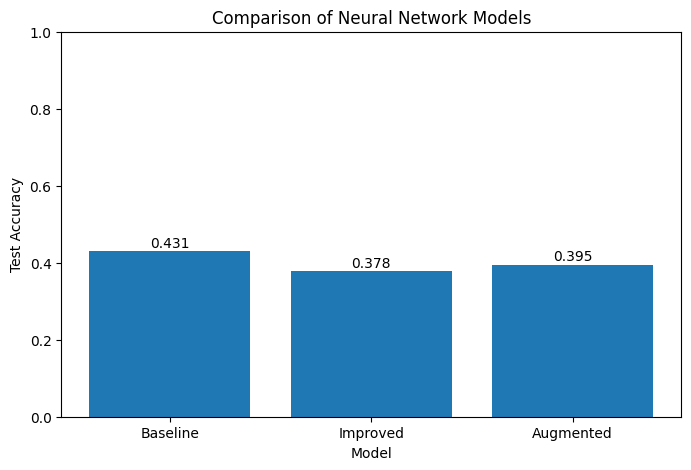

In [25]:
models = ["Baseline", "Improved", "Augmented"]
accuracy_values = [
    baseline_accuracy,
    improved_accuracy,
    augmented_accuracy
]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracy_values)

plt.title("Comparison of Neural Network Models")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(accuracy_values):
    plt.text(i, value + 0.01, f"{value:.3f}", ha="center")

plt.show()

In [26]:
model_dictionary = {
    "Baseline": baseline_model,
    "Improved": improved_model,
    "Augmented": augmented_model
}

best_model = model_dictionary[best_model_name]

print("Selected best model:", best_model_name)

Selected best model: Baseline


In [27]:
predictions = best_model.predict(x_test, verbose=0)

predicted_classes = np.argmax(predictions, axis=1)
actual_classes = y_test.flatten()

print("Predictions generated successfully.")
print("Number of test predictions:", len(predicted_classes))

Predictions generated successfully.
Number of test predictions: 10000


In [28]:
report = classification_report(
    actual_classes,
    predicted_classes,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

    airplane       0.53      0.46      0.49      1000
  automobile       0.57      0.56      0.56      1000
        bird       0.32      0.28      0.30      1000
         cat       0.35      0.26      0.30      1000
        deer       0.43      0.27      0.33      1000
         dog       0.42      0.31      0.36      1000
        frog       0.48      0.46      0.47      1000
       horse       0.30      0.73      0.42      1000
        ship       0.72      0.42      0.53      1000
       truck       0.49      0.56      0.52      1000

    accuracy                           0.43     10000
   macro avg       0.46      0.43      0.43     10000
weighted avg       0.46      0.43      0.43     10000



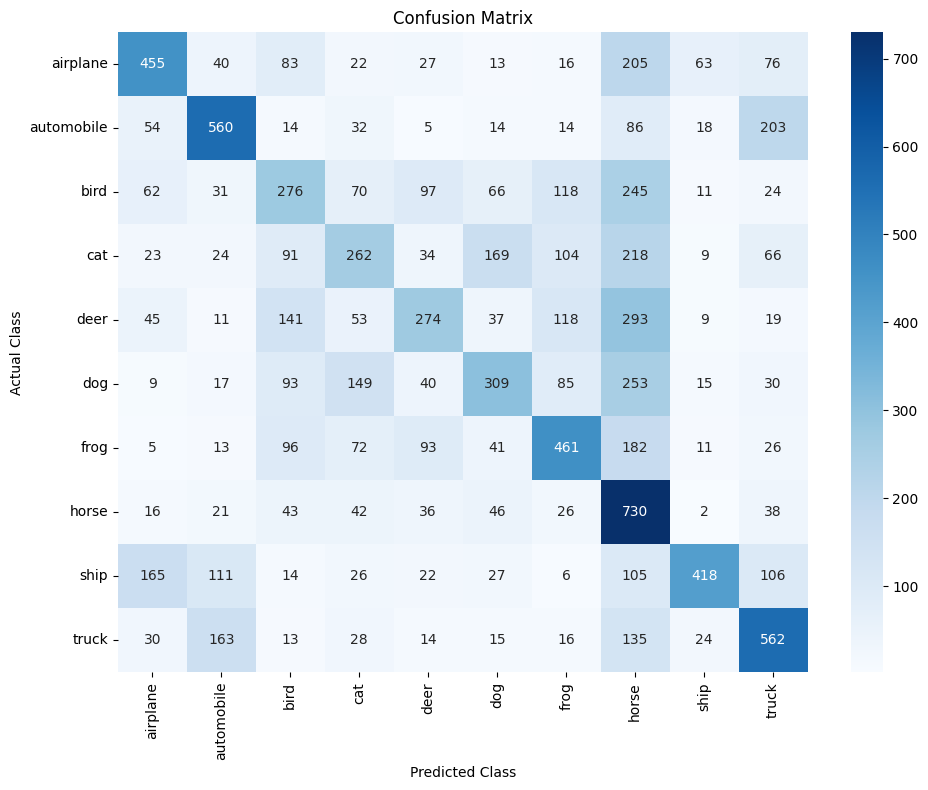

In [29]:
cm = confusion_matrix(
    actual_classes,
    predicted_classes
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

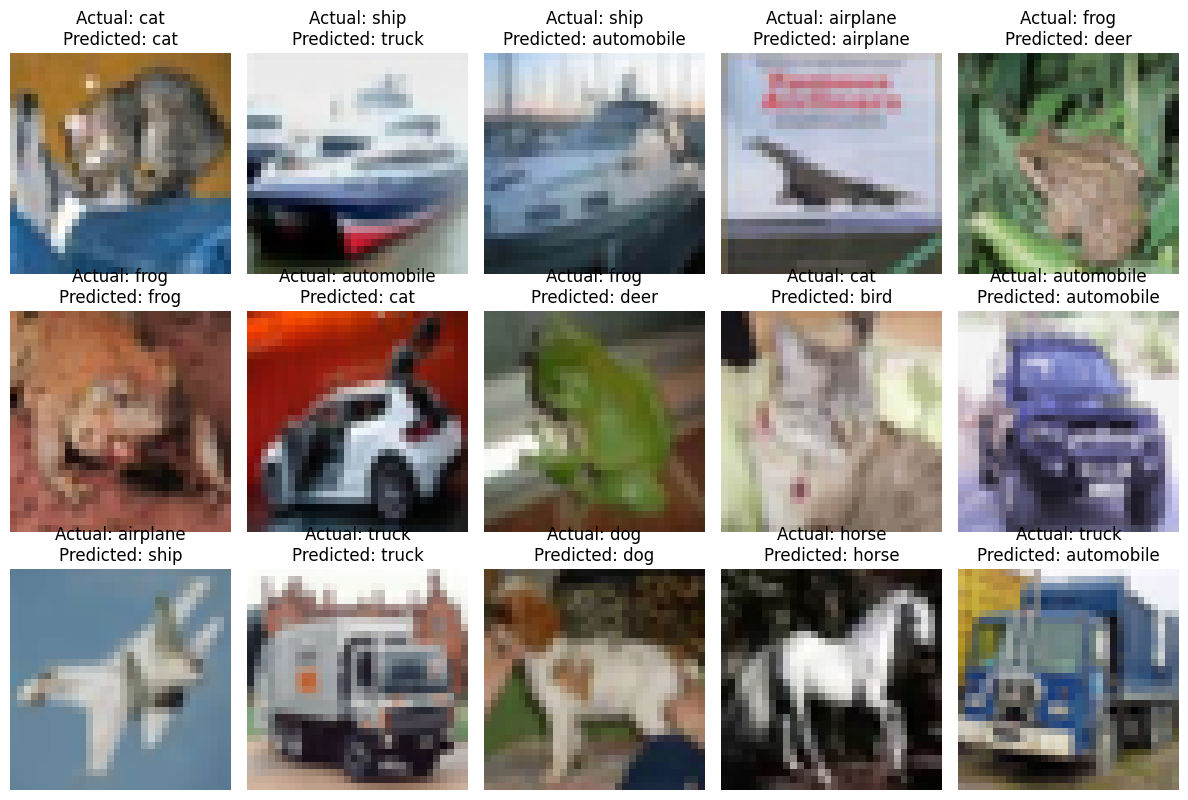

In [30]:
plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    plt.imshow(x_test[i])

    actual = class_names[actual_classes[i]]
    predicted = class_names[predicted_classes[i]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

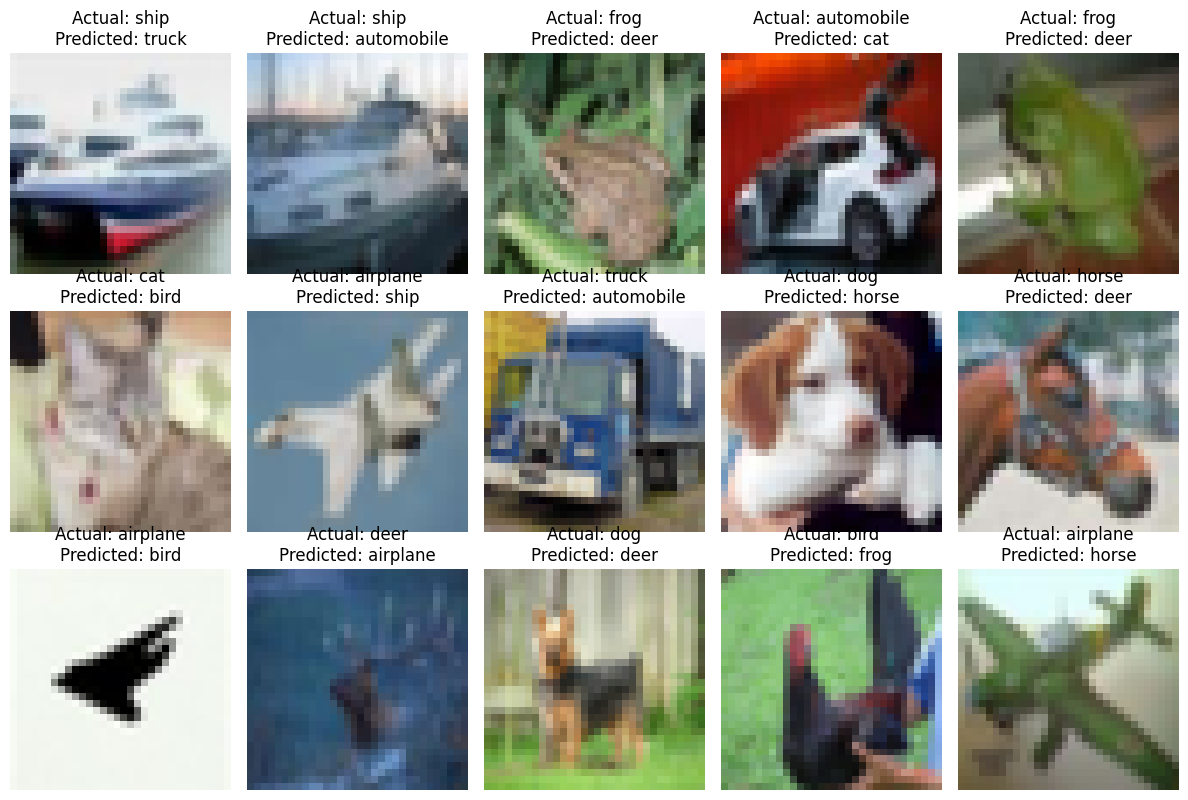

In [31]:
wrong_indices = np.where(predicted_classes != actual_classes)[0]

plt.figure(figsize=(12, 8))

for i in range(min(15, len(wrong_indices))):
    index = wrong_indices[i]

    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[index])

    actual = class_names[actual_classes[index]]
    predicted = class_names[predicted_classes[index]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
best_model.save("cifar10_neural_network.keras")

print("Best model saved successfully.")

Best model saved successfully.


In [33]:
print("=" * 50)
print("FINAL ASSIGNMENT RESULTS")
print("=" * 50)

print(f"Baseline test accuracy:  {baseline_accuracy:.4f}")
print(f"Improved test accuracy:  {improved_accuracy:.4f}")
print(f"Augmented test accuracy: {augmented_accuracy:.4f}")
print(f"Best model:              {best_model_name}")
print(f"Best test accuracy:      {accuracies[best_model_name]:.4f}")
print("=" * 50)

FINAL ASSIGNMENT RESULTS
Baseline test accuracy:  0.4307
Improved test accuracy:  0.3784
Augmented test accuracy: 0.3951
Best model:              Baseline
Best test accuracy:      0.4307


In [34]:
with open("classification_report.txt", "w") as f:
    f.write(report)

print("Classification report saved as classification_report.txt")

Classification report saved as classification_report.txt


In [35]:
with open("model_results.txt", "w") as f:
    f.write("CIFAR-10 Neural Network Results\n")
    f.write("=" * 40 + "\n")
    f.write(f"Baseline Accuracy: {baseline_accuracy:.4f}\n")
    f.write(f"Improved Accuracy: {improved_accuracy:.4f}\n")
    f.write(f"Augmented Accuracy: {augmented_accuracy:.4f}\n")
    f.write(f"Best Model: {best_model_name}\n")
    f.write(f"Best Accuracy: {accuracies[best_model_name]:.4f}\n")

print("Model results saved successfully.")

Model results saved successfully.
